In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import polyfit
import numpy as np




In [4]:
pDF = pd.read_excel('/Users/shawnlu/main/cmu/research/project/Coattail effect/data/raw_data/France_President_22.xlsx')
lDF = pd.read_excel('/Users/shawnlu/main/cmu/research/project/Coattail effect/data/raw_data/France_Parliament_noParis_22.xlsx')

In [5]:
# lDF[lDF['tour'] == 'round1'][lDF['Nuances'] == 'VEC']
lDF['Nuances'].unique()

array(['LR', 'NUP', 'RN', 'ENS', 'REC', 'ECO', 'DSV', 'DXG', 'DVD', 'DIV',
       'DVC', 'RDG', 'DVG', 'REG', 'UDI', 'DXD', nan], dtype=object)

In [6]:
pDF_first = pDF[pDF['tour'] == '*Rappel des Résultats du département au 1er tour']

pDF_first_lepen = pDF_first[pDF_first['candidats'] == 'Mme Marine LE PEN']
pDF_first_macron = pDF_first[pDF_first['candidats'] == 'M. Emmanuel MACRON']
pDF_first_zemmour = pDF_first[pDF_first['candidats'] == 'M. Éric ZEMMOUR']
pDF_first_Melenchon = pDF_first[pDF_first['candidats'] == 'M. Jean-Luc MÉLENCHON']
pDF_first_pecresse = pDF_first[pDF_first['candidats'] == 'Mme Valérie PÉCRESSE']
pDF_first__hidalgo = pDF_first[pDF_first['candidats'] == 'Mme Anne HIDALGO']


pDF_first = pDF_first_lepen.merge(pDF_first_macron, left_on=['Provence', 'Code', 'tour'], right_on=['Provence', 'Code', 'tour'])
pDF_first = pDF_first.merge(pDF_first_zemmour, left_on=['Provence', 'Code', 'tour'], right_on=['Provence', 'Code', 'tour'])
pDF_first = pDF_first.rename(columns={'Voix_x': 'LePen_votes',
                            'Inscrits_x': '%LePen_registered_share',
                            'Exprimés_x': '%LePen_share',
                            'Voix_y': 'Macron_votes',
                            'Inscrits_y': '%Macron_registered_share',
                            'Exprimés_y': '%Macron_share',
                            'Voix': 'zemmour_votes',
                            'Inscrits': '%zemmour_registered_share',
                            'Exprimés': '%zemmour_share'})
pDF_first = pDF_first.drop(['candidats_x', 'candidats_y'], axis=1)
pDF_first = pDF_first.merge(pDF_first_Melenchon, left_on=['Provence', 'Code', 'tour'], right_on=['Provence', 'Code', 'tour'])
pDF_first = pDF_first.rename(columns={
                            'Voix': 'Melenchon_votes',
                            'Inscrits': '%Melenchon_registered_share',
                            'Exprimés': '%Melenchon_share'})

pDF_first = pDF_first.merge(pDF_first_pecresse, left_on=['Provence', 'Code', 'tour'], right_on=['Provence', 'Code', 'tour'])
pDF_first = pDF_first.rename(columns={
                            'Voix': 'Pecresse_votes',
                            'Inscrits': '%Pecresse_registered_share',
                            'Exprimés': '%Pecresse_share'})
pDF_first = pDF_first.drop(['candidats'], axis=1)

pDF_first = pDF_first.merge(pDF_first__hidalgo, left_on=['Provence', 'Code', 'tour'], right_on=['Provence', 'Code', 'tour'])
pDF_first = pDF_first.rename(columns={
                            'Voix': 'hidalgo_votes',
                            'Inscrits': '%hidalgo_registered_share',
                            'Exprimés': '%hidalgo_share'})
pDF_first = pDF_first.drop(['candidats'], axis=1)

In [7]:
lDF_first = lDF[lDF['tour'] == 'round1']
lDF_first_RN = lDF_first[lDF_first['Nuances'] == 'RN']
lDF_first_ENS = lDF_first[lDF_first['Nuances'] == 'ENS']
lDF_first_LR = lDF_first[lDF_first['Nuances'] == 'LR']
lDF_first_REC = lDF_first[lDF_first['Nuances'] == 'REC']

In [8]:
print(lDF_first_RN.shape)
print(lDF_first_ENS.shape)
print(lDF_first_LR.shape)
print(lDF_first_REC.shape)

(528, 11)
(519, 11)
(419, 11)
(514, 11)


In [9]:
lDF_first_NUP = lDF_first[lDF_first['Nuances'] == 'NUP']
lDF_first_NUP.shape

(513, 11)

In [10]:
lDF_first = lDF[lDF['tour'] == 'round1']
lDF_first_RN = lDF_first[lDF_first['Nuances'] == 'RN']
lDF_first_RN = lDF_first_RN.rename(columns={'Voix': 'RN_votes',
                                            'Inscrits': '%RN_registered_share',
                                            'Exprimés': '%RN_share'})
lDF_first_RN['total_votes_RN'] = lDF_first_RN['RN_votes'] / lDF_first_RN['%RN_share'] * 100
lDF_first_RN['total_votes_RN'] = lDF_first_RN['total_votes_RN'].round(0)
lDF_first_RN = lDF_first_RN.groupby('Provence')[['RN_votes', 'total_votes_RN']].sum()
lDF_first_RN['%RN_share'] = lDF_first_RN['RN_votes'] / lDF_first_RN['total_votes_RN'] * 100

lDF_first_ENS = lDF_first[lDF_first['Nuances'] == 'ENS']
lDF_first_ENS = lDF_first_ENS.rename(columns={'Voix': 'ENS_votes',
                                            'Inscrits': '%ENS_registered_share',
                                            'Exprimés': '%ENS_share'})
lDF_first_ENS['total_votes_ENS'] = (lDF_first_ENS['ENS_votes'] / lDF_first_ENS['%ENS_share'] * 100)
lDF_first_ENS['total_votes_ENS'] = lDF_first_ENS['total_votes_ENS'].round(0)
lDF_first_ENS = lDF_first_ENS.groupby('Provence')[['ENS_votes', 'total_votes_ENS']].sum()
lDF_first_ENS['%ENS_share'] = lDF_first_ENS['ENS_votes'] / lDF_first_ENS['total_votes_ENS'] * 100


lDF_first_LR = lDF_first[lDF_first['Nuances'] == 'LR']
lDF_first_LR = lDF_first_LR.rename(columns={'Voix': 'LR_votes',
                                            'Inscrits': '%LR_registered_share',
                                            'Exprimés': '%LR_share'})
lDF_first_LR['total_votes_LR'] = (lDF_first_LR['LR_votes'] / lDF_first_LR['%LR_share'] * 100)
lDF_first_LR['total_votes_LR'] = lDF_first_LR['total_votes_LR'].round(0)
lDF_first_LR = lDF_first_LR.groupby('Provence')[['LR_votes', 'total_votes_LR']].sum()
lDF_first_LR['%LR_share'] = lDF_first_LR['LR_votes'] / lDF_first_LR['total_votes_LR'] * 100

lDF_first_NUP = lDF_first[lDF_first['Nuances'] == 'NUP']
lDF_first_NUP = lDF_first_NUP.rename(columns={'Voix': 'NUP_votes',
                                            'Inscrits': '%NUP_registered_share',
                                            'Exprimés': '%NUP_share'})
lDF_first_NUP['total_votes_NUP'] = (lDF_first_NUP['NUP_votes'] / lDF_first_NUP['%NUP_share'] * 100)
lDF_first_NUP['total_votes_NUP'] = lDF_first_NUP['total_votes_NUP'].round(0)
lDF_first_NUP = lDF_first_NUP.groupby('Provence')[['NUP_votes', 'total_votes_NUP']].sum()
lDF_first_NUP['%NUP_share'] = lDF_first_NUP['NUP_votes'] / lDF_first_NUP['total_votes_NUP'] * 100

lDF_first_REC = lDF_first[lDF_first['Nuances'] == 'REC']
lDF_first_REC = lDF_first_REC.rename(columns={'Voix': 'REC_votes',
                                            'Inscrits': '%REC_registered_share',
                                            'Exprimés': '%REC_share'})
lDF_first_REC['total_votes_REC'] = (lDF_first_REC['REC_votes'] / lDF_first_REC['%REC_share'] * 100)
lDF_first_REC['total_votes_REC'] = lDF_first_REC['total_votes_REC'].round(0)
lDF_first_REC = lDF_first_REC.groupby('Provence')[['REC_votes', 'total_votes_REC']].sum()
lDF_first_REC['%REC_share'] = lDF_first_REC['REC_votes'] / lDF_first_REC['total_votes_REC'] * 100

lDF_merge = lDF_first_RN.merge(lDF_first_ENS, left_on='Provence', right_on='Provence')
lDF_merge = lDF_merge.merge(lDF_first_LR, left_on='Provence', right_on='Provence')
lDF_merge = lDF_merge.merge(lDF_first_NUP, left_on='Provence', right_on='Provence')
lDF_merge = lDF_merge.merge(lDF_first_REC, left_on='Provence', right_on='Provence')

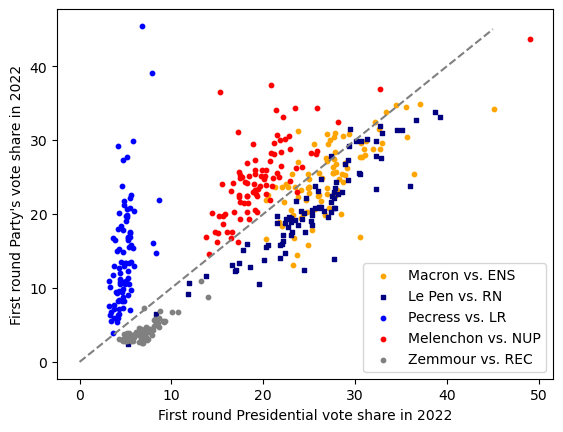

In [ ]:
mergeDF_first = pDF_first.merge(lDF_merge, left_on='Provence', right_on='Provence')

plt.scatter(mergeDF_first['%Macron_share'], mergeDF_first['%ENS_share'], s=10, color='orange', label='Macron vs. ENS')
# b, m = polyfit(mergeDF_first['%Macron_share'], mergeDF_first['%ENS_share'], 1)
# plt.plot(mergeDF_first['%Macron_share'], b + m * mergeDF_first['%Macron_share'], '-', color='orange', linewidth=0.8)

plt.scatter(mergeDF_first['%LePen_share'], mergeDF_first['%RN_share'], marker='s', s=10, color='navy', label='Le Pen vs. RN')
# b, m = polyfit(mergeDF_first['%LePen_share'], mergeDF_first['%RN_share'], 1)
# plt.plot(mergeDF_first['%LePen_share'], b + m * mergeDF_first['%LePen_share'], '-', color='navy', linewidth=0.8)

plt.scatter(mergeDF_first['%Pecresse_share'], mergeDF_first['%LR_share'], s=10, color='blue', label='Pecress vs. LR')
# b, m = polyfit(mergeDF_first['%Pecresse_share'], mergeDF_first['%LR_share'], 1)
# plt.plot(mergeDF_first['%Pecresse_share'], b + m * mergeDF_first['%Pecresse_share'], '-', color='blue', linewidth=0.8)

# plt.scatter(mergeDF_first['%Melenchon_share'], mergeDF_first['%NUP_share'], s=10, color='red', label='Melenchon vs. NUP')
# b, m = polyfit(mergeDF_first['%Melenchon_share'], mergeDF_first['%NUP_share'], 1)
# plt.plot(mergeDF_first['%Melenchon_share'], b + m * mergeDF_first['%Melenchon_share'], '-', color='red', linewidth=0.8)

plt.scatter(mergeDF_first['%zemmour_share'], mergeDF_first['%REC_share'], s=10, color='grey', label='Zemmour vs. REC')
# b, m = polyfit(mergeDF_first['%zemmour_share'], mergeDF_first['%REC_share'], 1)
# plt.plot(mergeDF_first['%zemmour_share'], b + m * mergeDF_first['%zemmour_share'], '-', color='grey', linewidth=0.8)

plt.plot([0, 45], [0, 45], color='gray', linestyle='--')
plt.legend()
plt.xlabel('First round Presidential vote share in 2022')
plt.ylabel("First round Party's vote share in 2022")
plt.show()

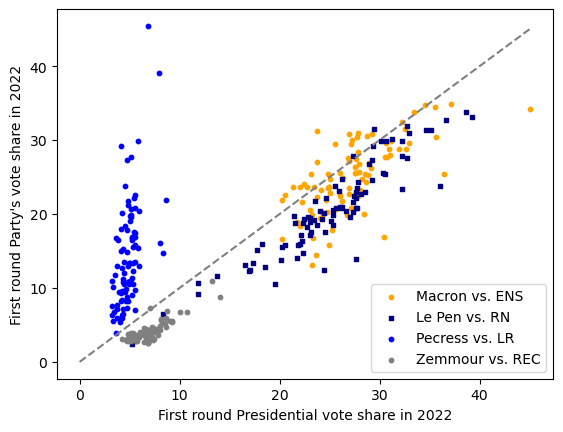

In [12]:
plt.scatter(mergeDF_first['%Macron_share'], mergeDF_first['%ENS_share'], s=10, color='orange', label='Macron vs. ENS')

plt.scatter(mergeDF_first['%LePen_share'], mergeDF_first['%RN_share'], marker='s', s=10, color='navy', label='Le Pen vs. RN')

plt.scatter(mergeDF_first['%Pecresse_share'], mergeDF_first['%LR_share'], s=10, color='blue', label='Pecress vs. LR')

# plt.scatter(mergeDF_first['%Melenchon_share'], mergeDF_first['%NUP_share'], s=10, color='red', label='Melenchon vs. NUP')
# b, m = polyfit(mergeDF_first['%Melenchon_share'], mergeDF_first['%NUP_share'], 1)
# plt.plot(mergeDF_first['%Melenchon_share'], b + m * mergeDF_first['%Melenchon_share'], '-', color='red', linewidth=0.8)

plt.scatter(mergeDF_first['%zemmour_share'], mergeDF_first['%REC_share'], s=10, color='grey', label='Zemmour vs. REC')

plt.plot([0, 45], [0, 45], color='gray', linestyle='--')
plt.legend()
plt.xlabel('First round Presidential vote share in 2022')
plt.ylabel("First round Party's vote share in 2022")
plt.show()

ticket splitting withing the coalition vs. ticket splitting accross the coalition
